 Querying global space archives for WASP-12...
Search Results Found:
SearchResult containing 14 data products.

 #     mission     year   author  exptime target_name distance
                                     s                 arcsec 
--- -------------- ---- --------- ------- ----------- --------
  0 TESS Sector 20 2019      SPOC     120    86396382      0.0
  1 TESS Sector 43 2021      SPOC     120    86396382      0.0
  2 TESS Sector 44 2021      SPOC     120    86396382      0.0
  3 TESS Sector 45 2021      SPOC     120    86396382      0.0
  4 TESS Sector 71 2023      SPOC      20    86396382      0.0
  5 TESS Sector 72 2023      SPOC      20    86396382      0.0
  6 TESS Sector 71 2023      SPOC     120    86396382      0.0
  7 TESS Sector 72 2023      SPOC     120    86396382      0.0
  8 TESS Sector 20 2019 TESS-SPOC    1800    86396382      0.0
  9 TESS Sector 43 2021 TESS-SPOC     600    86396382      0.0
 10 TESS Sector 44 2021 TESS-SPOC     600    86396382      0.0
 11 TE

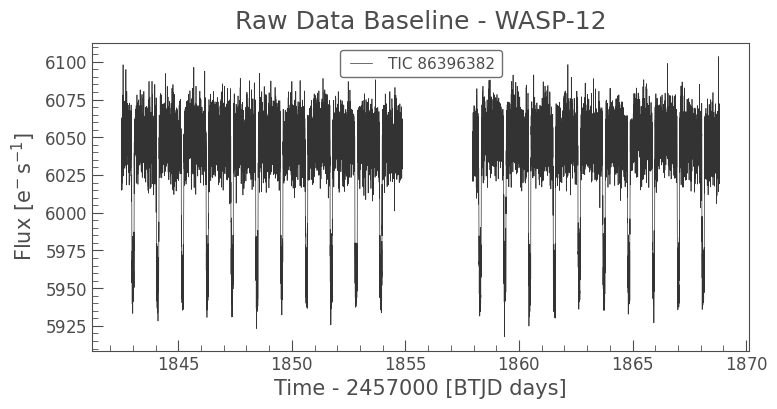

In [11]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
target_star = "WASP-12" 

print(f" Querying global space archives for {target_star}...")
search_results = lk.search_lightcurve(target_star, author=("Kepler", "SPOC", "TESS-SPOC"))# opening it to other author not just kepler
print("Search Results Found:")
print(search_results)

print("Stream-loading files into memory...")
raw_lc = search_results[0].download()
print(f" Success! Loaded data from mission: {raw_lc.meta.get('MISSION')}")

# Plot the raw result
raw_lc.plot(title=f"Raw Data Baseline - {target_star}")
plt.show()

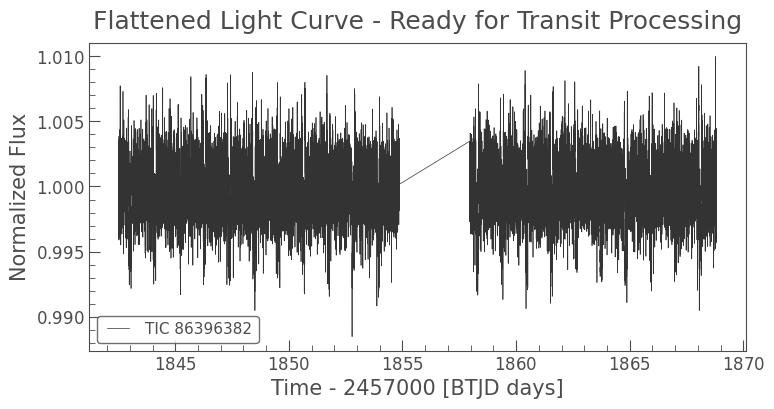

In [12]:
# Removing any corrupted rows from the data arrays
#NaNs and outliers — sometimes a cosmic ray hits the detector, or the telescope drifts slightly, causing a single brightness reading to spike wildly
clean_lc = raw_lc.remove_nans()

#  then we remove extreme outlying data spikes, (if its more than 5 stand deviation)
clean_lc = clean_lc.remove_outliers(sigma=5.0)
#using code available to:
# Apply a sliding filter window to flatten out macro stellar rotation trends
# This isolates the quick, distinct planetary transit dips
flat_lc = clean_lc.flatten(window_length=101)

flat_lc.plot(title="Flattened Light Curve - Ready for Transit Processing")
plt.show()

🎯 Target Found!
Identified Orbital Period: 1.0909090909090908 d
Identified Epoch Center Time (t0): 1843.0095101849984


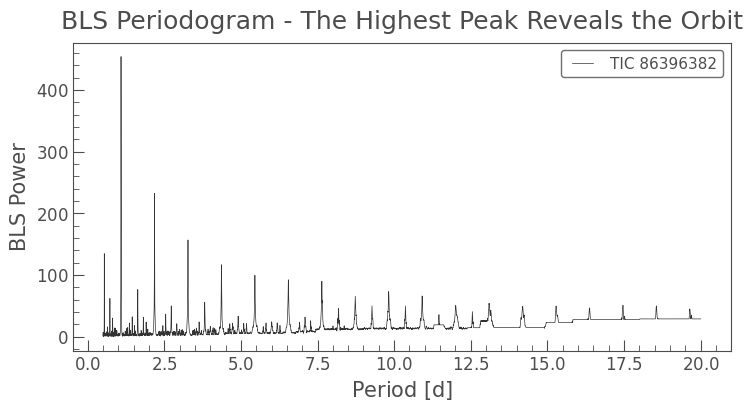

In [13]:
#how often those dips repeat, their period.
periodogram = flat_lc.to_periodogram(method='bls', period=np.linspace(0.5, 20, 10000))
#we are using BLS algo to create 10,000 evenly spaced period candidates between 0.5 and 20 days to test

# Extracting  the strongest candidate parameters discovered by BLS
best_period = periodogram.period_at_max_power
best_t0 = periodogram.transit_time_at_max_power

print(f"🎯 Target Found!")
print(f"Identified Orbital Period: {best_period}")
print(f"Identified Epoch Center Time (t0): {best_t0}")

# Ploting the periodogram spectrum power peaks
periodogram.plot(title="BLS Periodogram - The Highest Peak Reveals the Orbit")
plt.show()

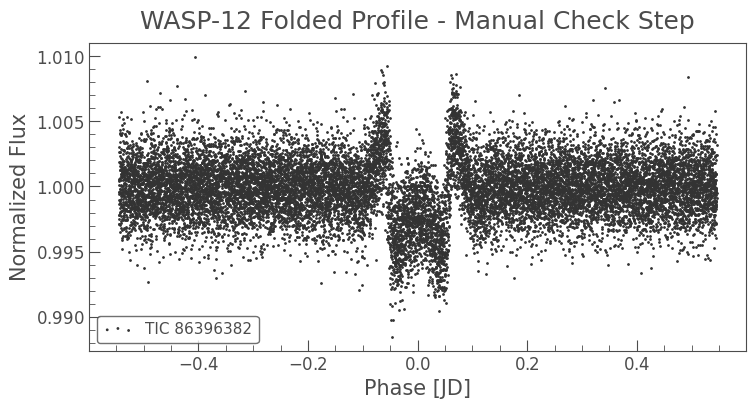

In [14]:
# Fold the data arrays around the calculated period matrix
folded_lc = flat_lc.fold(period=best_period, epoch_time=best_t0)

# Plot the final folded results to visually check for a clear U-shaped dip
folded_lc.scatter(title=f"{target_star} Folded Profile - Manual Check Step")
plt.show()
#                       ======For our reference======
#       TRUE EXOPLANET                    ECLIPSING BINARY STAR               INSTRUMENTAL NOISE
#       
#  Baseline (1.0)                      Baseline (1.0)                      Baseline (1.0)
# ───┐          ┌───                  ───\          /───                  ───┐  ┌┐  ┌───
#    │          │                        \        /                          └──┘└──┘
#    └──────────┘                         \      /                        Random Jagged 
#   Flat, Square "U-Shape"               Sharp "V-Shape"                     Artifacts
#  (Planet blocks light evenly)        (Star grazes behind another)       (No physical curve)


In [15]:
import numpy as np
import pandas as pd
import lightkurve as lk
import scipy.stats as stats

def convert_to_1d_vector(folded_lc, num_bins=200):
    """
    Compresses a scattered phase-folded light curve into a 
    standardized 1D array vector of fixed length.
    """
    # Creates a phase -0.5 to +0.5, total width = +1, for bining.
    bin_edges = np.linspace(-0.5, 0.5, num_bins + 1)
    
    # Calculating the median for each bin intervals
    bin_means, _, _ = stats.binned_statistic(
        folded_lc.phase.value, 
        folded_lc.flux.value, 
        statistic='median', 
        bins=bin_edges
    )
    
    # Cleaning up any empty bin, (Nan) by making it 1.0
    bin_means = np.nan_to_num(bin_means, nan=1.0)
    
    # Normalize the vector so it scales perfectly between 0 and 1 for the model
    normalized_vector = (bin_means - np.min(bin_means)) / (np.max(bin_means) - np.min(bin_means) + 1e-8)
    
    return normalized_vector

# test the binner on a mix of a Planet and a Random Star ---
test_targets = ["Kepler-10", "KIC 7574507"]
dataset = {}

for star in test_targets:
    print(f"Bulk Processing: {star}")
    try:
        search = lk.search_lightcurve(star, author="Kepler", quarter=3, exptime="long")
        if len(search) == 0: continue
        
        lc = search.download().remove_nans().remove_outliers(sigma=5.0)
        flat = lc.flatten(window_length=101)
        pg = flat.to_periodogram(method='bls', period=np.linspace(0.5, 20, 5000))
        
        folded = flat.fold(period=pg.period_at_max_power, epoch_time=pg.transit_time_at_max_power)
        
        # Convert our image profile into a 1D Mathematical Vector array!
        vector = convert_to_1d_vector(folded, num_bins=200)
        dataset[star] = vector
        print(f" Vector generated! Shape: {vector.shape}")
        
    except Exception as e:
        print(f"Skipped {star} due to exception:{e}")

Bulk Processing: Kepler-10
 Vector generated! Shape: (200,)
Bulk Processing: KIC 7574507


In [16]:
import numpy as np
import pandas as pd
import lightkurve as lk
import scipy.stats as stats

def convert_to_1d_vector(folded_lc, num_bins=200):
    """
    Compresses a scattered phase-folded light curve into a 
    standardized 1D array vector of fixed length.
    """
    # Creates a phase -0.5 to +0.5, total width = +1, for bining.
    bin_edges = np.linspace(-0.5, 0.5, num_bins + 1)
    
    # Calculating the median for each bin intervals
    bin_means, _, _ = stats.binned_statistic(
        folded_lc.phase.value, 
        folded_lc.flux.value, 
        statistic='median', 
        bins=bin_edges
    )
    
    # Cleaning up any empty bin, (Nan) by making it 1.0
    bin_means = np.nan_to_num(bin_means, nan=1.0)
    
    # Normalize the vector so it scales perfectly between 0 and 1 for the model
    normalized_vector = (bin_means - np.min(bin_means)) / (np.max(bin_means) - np.min(bin_means) + 1e-8)
    
    return normalized_vector

# test the binner on a mix of a Planet and a Random Star ---
test_targets = [
    "Kepler-10",       # Confirmed Planet (Kepler-10b)
    "Kepler-90",       # Confirmed Planet (Kepler-90h)
    "WASP-12",         # Confirmed Planet (WASP-12b)
    "KIC 11548140",    # Confirmed Eclipsing Binary Star (V-shape false positive noise)
    "KIC 6352430",     # Confirmed Eclipsing Binary Star (False positive noise)
    "KIC 3240343"      # Confirmed Variable Star (Stellar pulsation noise)
]
dataset = {}

for star in test_targets:
    print(f"Bulk Processing: {star}")
    try:
        search = lk.search_lightcurve(star, author="Kepler", quarter=3, exptime="long")
        if len(search) == 0: continue
        
        lc = search.download().remove_nans().remove_outliers(sigma=5.0)
        flat = lc.flatten(window_length=101)
        pg = flat.to_periodogram(method='bls', period=np.linspace(0.5, 20, 5000))
        
        folded = flat.fold(period=pg.period_at_max_power, epoch_time=pg.transit_time_at_max_power)
        
        # Convert our image profile into a 1D Mathematical Vector array!
        vector = convert_to_1d_vector(folded, num_bins=200)
        dataset[star] = vector
        print(f" Vector generated! Shape: {vector.shape}")
        
    except Exception as e:
        print(f"Skipped {star} due to exception:{e}")

Bulk Processing: Kepler-10
 Vector generated! Shape: (200,)
Bulk Processing: Kepler-90
 Vector generated! Shape: (200,)
Bulk Processing: WASP-12
Bulk Processing: KIC 11548140
 Vector generated! Shape: (200,)
Bulk Processing: KIC 6352430
 Vector generated! Shape: (200,)
Bulk Processing: KIC 3240343


Could not resolve "KIC 3240343" to a sky position.


In [17]:
import torch
import torch.nn as nn

class ExoplanetVettingCNN(nn.Module):
    def __init__(self):
        super(ExoplanetVettingCNN, self).__init__()
        
        #looking for any sudden drops and patterns, relu makes any negative to an absolute zero, pool is to compress
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2) # Compresses length from 200 down to 100
        
        # Extracts the patterns we observe: U&V pattern.
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2) # Compresses length from 100 down to 50
        
        # Layer 3: Fully Connected Decision Layer
        self.fc1 = nn.Linear(32 * 50, 64)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(64, 1) # Outputs a single value
        self.sigmoid = nn.Sigmoid()  # Squashes output between 0.0 (Noise) and 1.0 (Planet Candidate)
        
    def forward(self, x):
        # x must enter with shape shape: [Batch_Size, 1, 200]
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        
        # Flatten the matrix features into a long single-file row vector
        x = x.view(x.size(0), -1) 
        
        x = self.relu3(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

# Instantiate our Neural Network brain!
model = ExoplanetVettingCNN()
print("\n🤖 1D-CNN Model Architecture successfully compiled:")
print(model)


🤖 1D-CNN Model Architecture successfully compiled:
ExoplanetVettingCNN(
  (conv1): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (relu2): ReLU()
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1600, out_features=64, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [18]:
import torch
import torch.optim as optim
import torch.nn as nn
# Making a training batch for the network
X_list = []
y_list = []

#  absolute answer keys 
labels = {
    "Kepler-10": 1.0,     # True Planet  (Positive class)
    "Kepler-90": 1.0,     # True Planet (Positive class)
    "KIC 11548140": 0.0,  # Astrophysical False Positive Noise (Negative class)
    "KIC 6352430": 0.0    # Astrophysical False Positive Noise (Negative class)
}

for star, vector in dataset.items():
    if star in labels:
        X_list.append(vector)
        y_list.append(labels[star])

# Convert lists into PyTorch Tensors. 
X = torch.tensor(np.array(X_list), dtype=torch.float32).unsqueeze(1) # [Batch size: 4 inputs, 1 channel, 200 array bins]
y = torch.tensor(np.array(y_list), dtype=torch.float32).unsqueeze(1) # [Batch size: 4 expected answer flags, 1 target output]
# 2. CHOOSE THE OBJECTIVE METRICS & GRADIENT MECHANICS
# It mathematically penalizes the model when its continuous probability guess deviates from the truth.(Binary Cross Entropy loss)
criterion = nn.BCELoss() 

# Adam Optimization Engine manages parameters just like it scales parameters across modern transformers.
optimizer = optim.Adam(model.parameters(), lr=0.005)

# 3. TRAINING LOOP EXECUTION
epochs = 50
print("Training our 1D-CNN Model across cosmic signatures...\n")

for epoch in range(1, epochs + 1):
    model.train()
        # Drops the calculated adjustments from the previous round so gradients don't pile up.
    optimizer.zero_grad()
    
    # Forward Pass
    predictions = model(X)
    
    #Loss
    loss = criterion(predictions, y)
    
    # Backpropagation 
    loss.backward()
    
    # Weight Adjustment, Optimisation step
    # Tweeks the internal convolutional matrix weight numbers by a minute fraction,to guarantee the predictions become slightly more accurate on the next iteration loop.
    optimizer.step()
    
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch [{epoch}/{epochs}] ─── Loss: {loss.item():.4f}")

print(" Training Complete! The Convolutional filters have adapted to the signal vectors.")

Training our 1D-CNN Model across cosmic signatures...

Epoch [1/50] ─── Loss: 0.6957
Epoch [10/50] ─── Loss: 0.4166
Epoch [20/50] ─── Loss: 0.0027
Epoch [30/50] ─── Loss: 0.0000
Epoch [40/50] ─── Loss: 0.0000
Epoch [50/50] ─── Loss: 0.0000
 Training Complete! The Convolutional filters have adapted to the signal vectors.


In [19]:
# AUTOMATED INFERENCE 

def automated_exoplanet(star_name):
    """
    Takes an unknown target star, automatically conditions the signal, 
    and lets the trained 1D-CNN issue a classification verdict.
    """
    print(f"INITIATING AUTOMATED VETTING FOR: {star_name}")
    model.eval()  # Sets the network to evaluation mode (turns off gradient tracking)
    
    try:
        #Programmatically grab the data stream from MAST archives
        search = lk.search_lightcurve(star_name, author="Kepler", quarter=3, exptime="long")
        if len(search) == 0:
            print(f"Aborted: No valid data found for {star_name} under Kepler Quarter 3.")
            return
        
        #  Run through our automated Step 1 signal conditioning steps
        lc = search.download().remove_nans().remove_outliers(sigma=5.0)
        flat = lc.flatten(window_length=101)
        pg = flat.to_periodogram(method='bls', period=np.linspace(0.5, 20, 5000))
        folded = flat.fold(period=pg.period_at_max_power, epoch_time=pg.transit_time_at_max_power)
        
        # Compress the scattered image arrays into our standardized 1D vector
        vector = convert_to_1d_vector(folded, num_bins=200)
        
        #  Convert the array to a PyTorch tensor and match input shapes [1, 1, 200]
        input_tensor = torch.tensor(vector, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        
        # Step 5: Forward Pass,lets predit
        with torch.no_grad():
            confidence_score = model(input_tensor).item()
        
        print(f"AUTOMATED REPORT FOR {star_name} is ")
        print(f"The Candidate Confidence Score: {confidence_score * 100:.2f}%")
        
        if confidence_score >= 0.70:
            print("VERDICT: POSITIVE. Do a follow-up.")
        else:
            print("VERDICT: NEGATIVE. Signal matches background noise.")
            
    except Exception as e:
        print(f"Inference pipeline failed for {star_name} due to error: {e}")
automated_exoplanet("Kepler-10")#known postive
automated_exoplanet("KIC 11548140")#known negative
automated_exoplanet("KIC 8462852")

INITIATING AUTOMATED VETTING FOR: Kepler-10
AUTOMATED REPORT FOR Kepler-10 is 
The Candidate Confidence Score: 100.00%
VERDICT: POSITIVE. Do a follow-up.
INITIATING AUTOMATED VETTING FOR: KIC 11548140
AUTOMATED REPORT FOR KIC 11548140 is 
The Candidate Confidence Score: 0.00%
VERDICT: NEGATIVE. Signal matches background noise.
INITIATING AUTOMATED VETTING FOR: KIC 8462852
AUTOMATED REPORT FOR KIC 8462852 is 
The Candidate Confidence Score: 0.00%
VERDICT: NEGATIVE. Signal matches background noise.


STARTING COSMIC HARVEST SURVEY ACROSS 10 TARGETS...
🟩 MATCH FOUND! Kepler-10 flagged with 100.00% confidence.


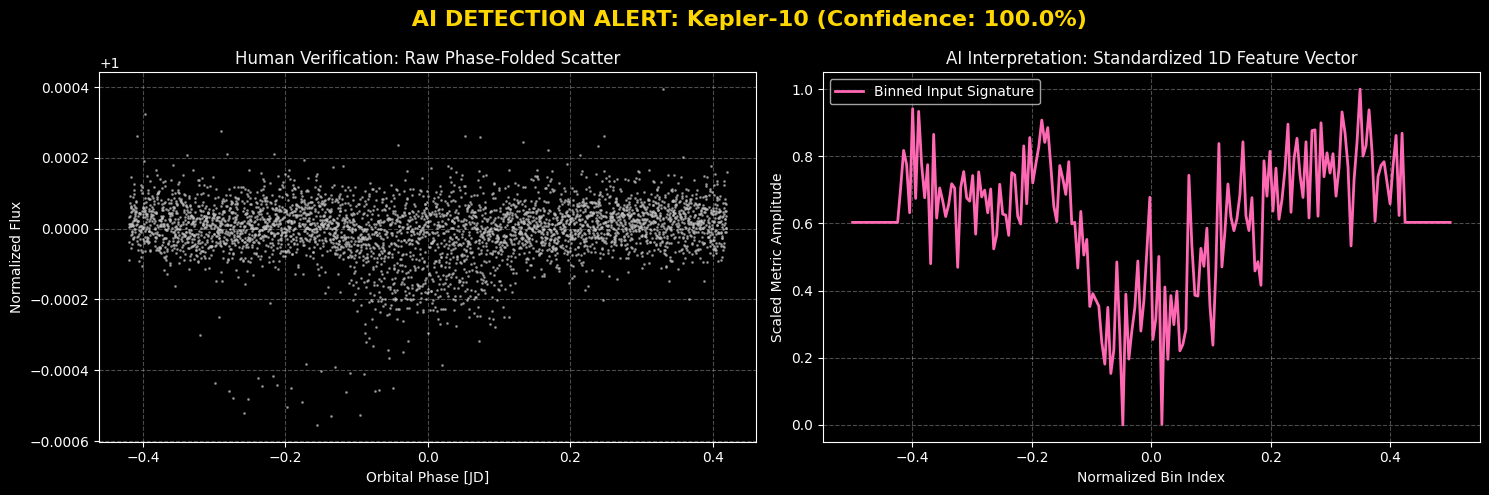

Skipped KIC 11548140: Evaluated as background noise (0.00%)
🟩 MATCH FOUND! Kepler-90 flagged with 100.00% confidence.


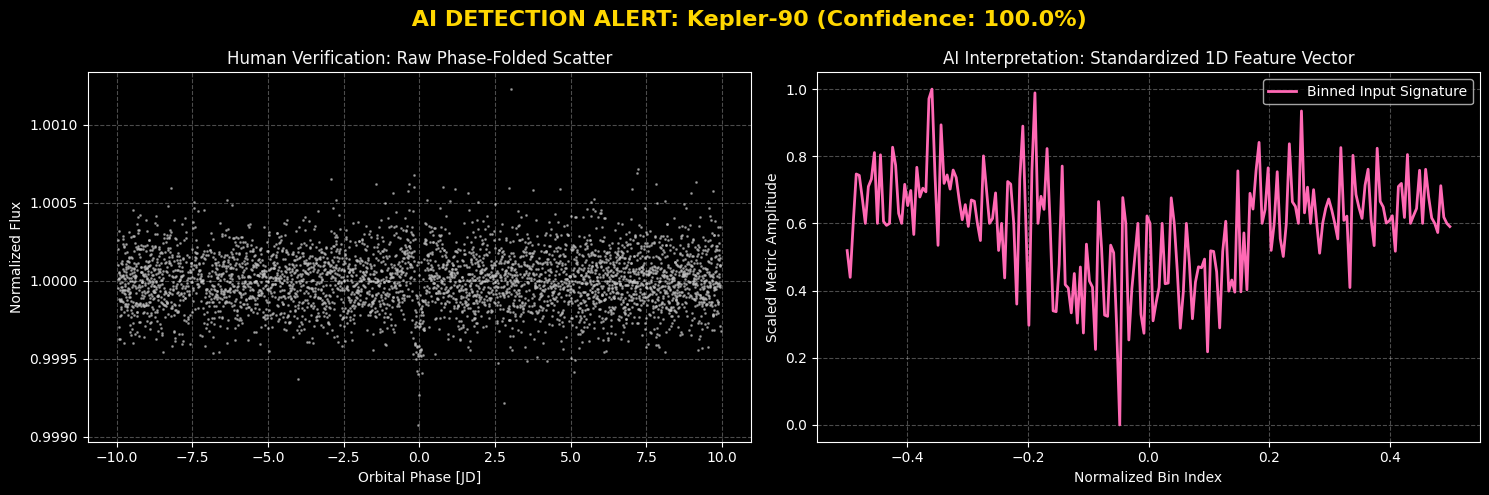

Skipped KIC 6352430: Evaluated as background noise (0.00%)
🟩 MATCH FOUND! Kepler-12 flagged with 100.00% confidence.


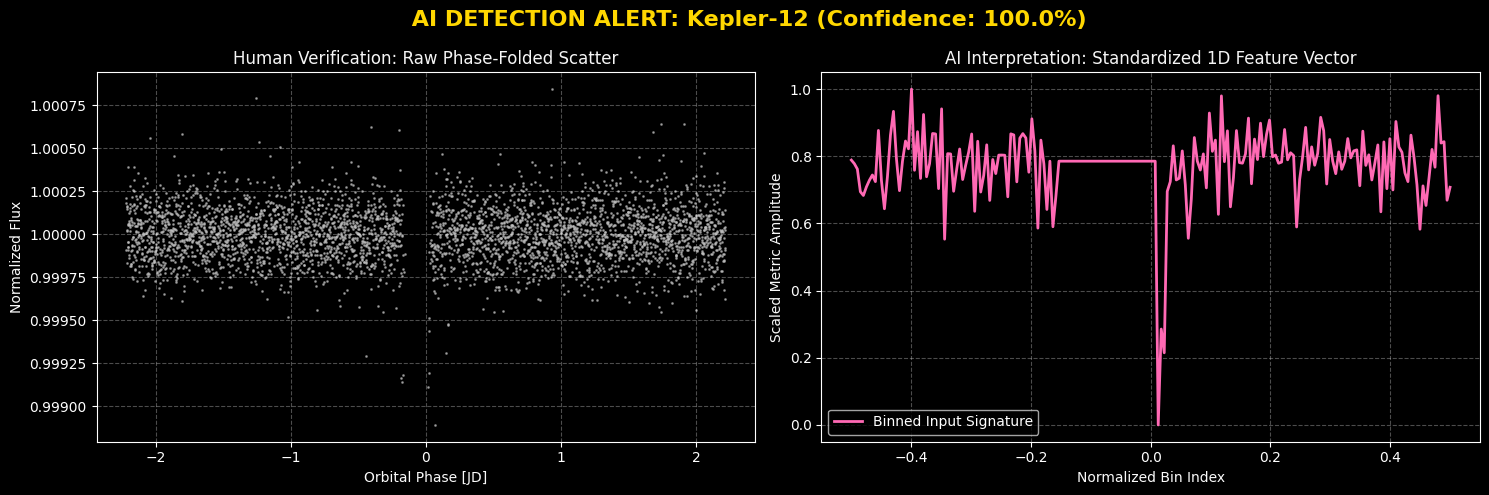

🟩 MATCH FOUND! Kepler-62 flagged with 100.00% confidence.


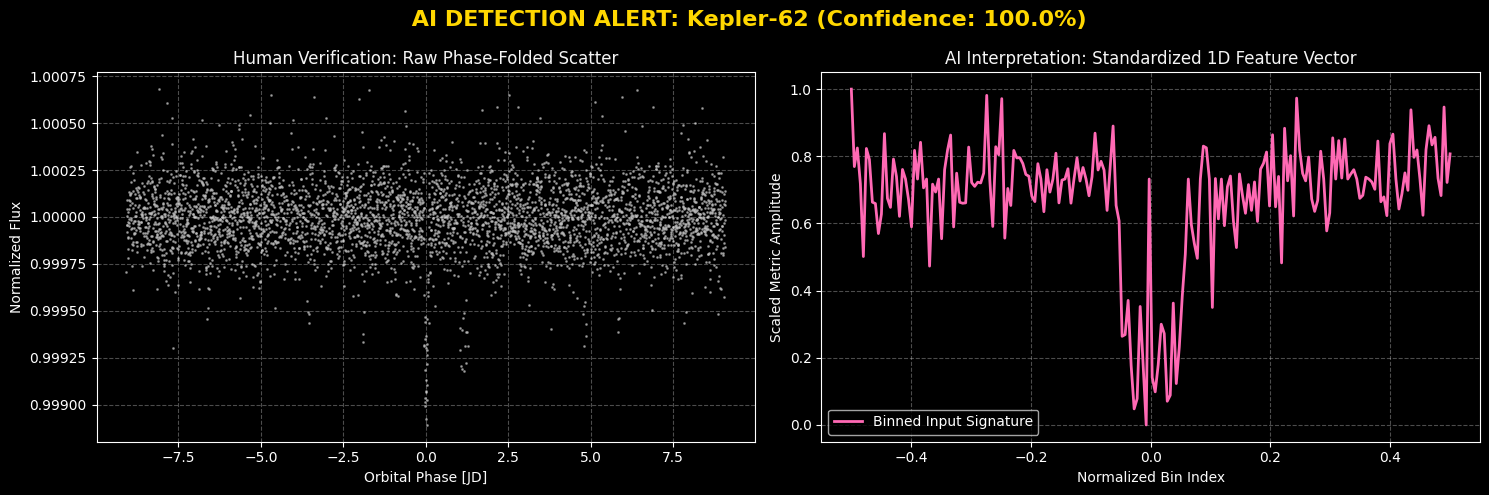

Skipped KIC 8462852: Evaluated as background noise (0.00%)
🟩 MATCH FOUND! Kepler-8 flagged with 100.00% confidence.


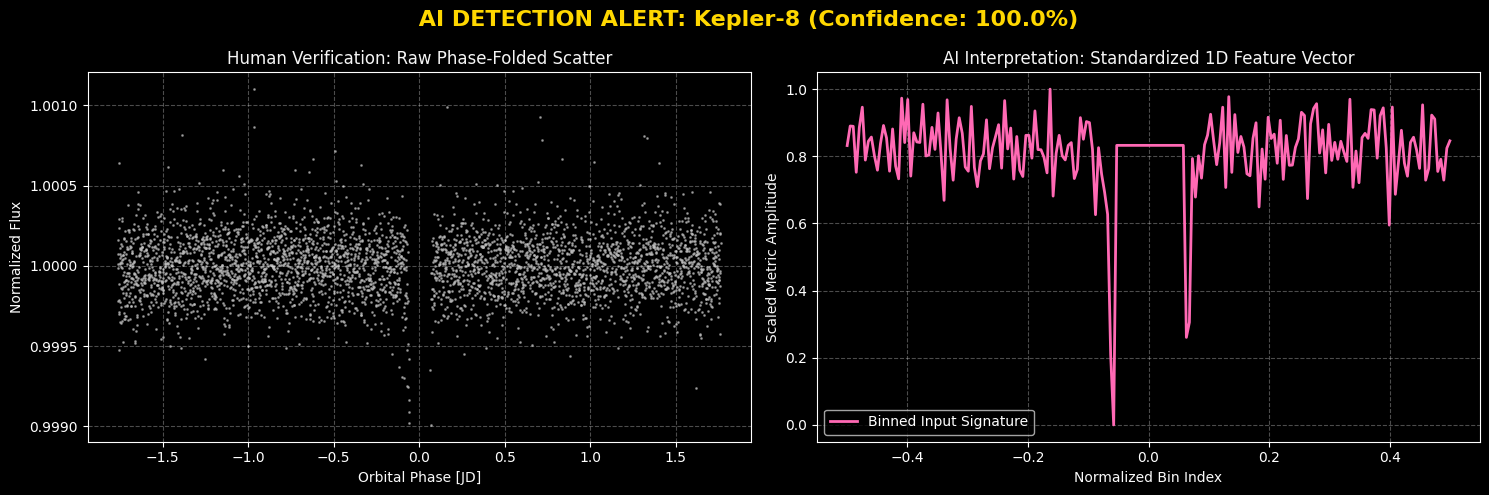


FINAL HARVEST REPORT SPREADSHEET SUMMARY:
     Star Confidence Period_Days
Kepler-10    100.00%      0.8394
Kepler-90    100.00%     19.9142
Kepler-12    100.00%      4.4398
Kepler-62    100.00%     18.1588
 Kepler-8    100.00%      3.5231

Saved master detection file to: 'ai_exoplanet_discoveries.csv'


In [20]:
# ==================================================================================
# 1. CORE DEPENDENCY IMPORTS (Moved to the absolute top to prevent compilation NameErrors)
# ==================================================================================
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# ==================================================================================
# 2. SAFE ENV FALLBACK INITIALIZATION
# ==================================================================================
# First, ensure the neural network class blueprint exists in memory
if 'ExoplanetVettingCNN' not in locals() and 'ExoplanetVettingCNN' not in globals():
    print("🧠 Class blueprint missing from RAM. Defining ExoplanetVettingCNN structure...")
    class ExoplanetVettingCNN(nn.Module):
        def __init__(self):
            super(ExoplanetVettingCNN, self).__init__()
            self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2)
            self.relu1 = nn.ReLU()
            self.pool1 = nn.MaxPool1d(kernel_size=2)
            self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=2)
            self.relu2 = nn.ReLU()
            self.pool2 = nn.MaxPool1d(kernel_size=2)
            self.fc1 = nn.Linear(32 * 50, 64)
            self.relu3 = nn.ReLU()
            self.fc2 = nn.Linear(64, 1)
            self.sigmoid = nn.Sigmoid()
            
        def forward(self, x):
            x = self.pool1(self.relu1(self.conv1(x)))
            x = self.pool2(self.relu2(self.conv2(x)))
            x = x.view(x.size(0), -1) 
            x = self.relu3(self.fc1(x))
            x = self.sigmoid(self.fc2(x))
            return x

# Second, instantiate the model object if it doesn't exist
if 'model' not in locals() and 'model' not in globals():
    print("🤖 model variable not found in RAM. Initializing network architecture...")
    model = ExoplanetVettingCNN()

# ==================================================================================
# 3. HARVESTER AND VISUALIZER FUNCTION
# ==================================================================================
def candidates_vis(star_list):
    """
    Loops through a batch of stars, uses the trained 1D-CNN to screen them,
    and automatically generates deep diagnostic plots ONLY for positive planet candidates.
    """
    print(f"STARTING COSMIC HARVEST SURVEY ACROSS {len(star_list)} TARGETS...")
    print("==================================================================")
    
    model.eval()
    discovered_candidates = []
    
    for star in star_list:
        try:
            # Search from MAST
            search = lk.search_lightcurve(star, author="Kepler", quarter=3, exptime="long")
            if len(search) == 0:
                continue
                
            lc = search.download().remove_nans().remove_outliers(sigma=5.0)
            flat = lc.flatten(window_length=101)
            pg = flat.to_periodogram(method='bls', period=np.linspace(0.5, 20, 5000))
            
            best_p = pg.period_at_max_power
            best_t0 = pg.transit_time_at_max_power
            folded = flat.fold(period=best_p, epoch_time=best_t0)
            
            # Vectorization (Binning)
            vector = convert_to_1d_vector(folded, num_bins=200)
            
            # Neural Network Inference Pass
            input_tensor = torch.tensor(vector, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
            with torch.no_grad():
                confidence = model(input_tensor).item()
            
            # Gating Decision Logic
            if confidence >= 0.70:
                print(f"🟩 MATCH FOUND! {star} flagged with {confidence*100:.2f}% confidence.")
                discovered_candidates.append({
                    "Star": star,
                    "Confidence": f"{confidence*100:.2f}%",
                    "Period_Days": f"{best_p.value:.4f}"
                })
                
                # --- OPTION C: ALERT INTERACTIVE VISUALIZATION ---
                plt.style.use('dark_background')
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
                fig.suptitle(f" AI DETECTION ALERT: {star} (Confidence: {confidence*100:.1f}%)", 
                             color='#FFD700', fontsize=16, fontweight='bold')
                
                # The Human Astro View (Raw Scatter)
                ax1.scatter(folded.phase.value, folded.flux.value, s=1, color='#C0C0C0', alpha=0.6)
                ax1.set_title("Human Verification: Raw Phase-Folded Scatter", color='#F5F5F5')
                ax1.set_xlabel("Orbital Phase [JD]", color='#FAFAFA')
                ax1.set_ylabel("Normalized Flux", color='#FAFAFA')
                ax1.grid(True, linestyle='--', alpha=0.3)
                
                # The Machine Learning Input View (Binned 1D Vector)
                ax2.plot(np.linspace(-0.5, 0.5, 200), vector, color='#FF69B4', linewidth=2, label="Binned Input Signature")
                ax2.set_title("AI Interpretation: Standardized 1D Feature Vector", color='#F5F5F5')
                ax2.set_xlabel("Normalized Bin Index", color='#FAFAFA')
                ax2.set_ylabel("Scaled Metric Amplitude", color='#FAFAFA')
                ax2.grid(True, linestyle='--', alpha=0.3)
                ax2.legend()
                
                plt.tight_layout()
                plt.show()
                
            else:
                print(f"Skipped {star}: Evaluated as background noise ({confidence*100:.2f}%)")
                
        except Exception as e:
            continue
            
    print("\n==================================================================")
    print("FINAL HARVEST REPORT SPREADSHEET SUMMARY:")
    if discovered_candidates:
        df = pd.DataFrame(discovered_candidates)
        df.to_csv("ai_exoplanet_discoveries.csv", index=False)
        print(df.to_string(index=False))
        print("\nSaved master detection file to: 'ai_exoplanet_discoveries.csv'")
    else:
        print("No planet candidates crossed the 70% threshold in this batch.")

# ==================================================================================
# 4. EXECUTE SURVEY SURVEY
# ==================================================================================
survey_batch = [
    "Kepler-10", "KIC 11548140", "Kepler-90", "KIC 6352430", 
    "Kepler-12", "KIC 5000002", "KIC 7574507", "Kepler-62", 
    "KIC 8462852", "Kepler-8"
]

candidates_vis(survey_batch)